# Análisis Predictivo - Evaluación 3

## <span style="color:cyan"> Daniela Higuita Agudelo :)

El archivo que se le suministra es un conjunto de datos de pacientes con cáncer de mama se obtuvo de la actualización de noviembre de 2017 del Programa SEER del NCI, que proporciona información sobre estadísticas de cáncer basadas en la población. El conjunto de datos incluyó a pacientes de sexo femenino con cáncer de mama de carcinoma lobular y ductal infiltrante (códigos histológicos 8522/3 de recodificación NOS de citas primarias del SEER) diagnosticado entre 2006 y 2010.

Las variables que contiene este dataset son:

1. Age: Se refiere a la edad del paciente en el momento del diagnóstico.
2. Race: raza o etnia del paciente.
3. Marital Status: El estado civil del paciente (casado, soltero, divorciado, etc.).
4. T Stage: La clasificación del tamaño o extensión del tumor primario (normalmente se utiliza en el sistema TNM).
5. N Stage: Se refiere a la extensión del cáncer a los ganglios linfáticos cercanos.
6. 6th State: Puede referirse al estadio del cáncer según una clasificación específica (como la clasificación AJCC).
7. differentiate: Se refiere al grado de diferenciación celular del tumor (lo diferentes que son las células tumorales de las células normales), un factor utilizado para determinar la agresividad del cáncer.
8. Grade: Se refiere al grado de progresión del tumor o cáncer y a cuánto se ha extendido.
9. A Stage: Puede referirse a un estadio específico en la clasificación por estadios del cáncer.
10. Tumor Size: El tamaño medido del tumor primario.
11. Estrogen Status: Estado de los receptores de estrógenos en las células cancerosas (positivo o negativo), que afecta al tratamiento.
12. Progesterone Status: Estado de los receptores de progesterona en las células cancerosas (positivo o negativo).
13. Regional Node Examined: El número de ganglios linfáticos examinados para detectar la propagación del cáncer.
14. Reginol Node Positive: El número de ganglios linfáticos que dieron positivo para el cáncer.
15. Survival Monyhs: El número de meses que el paciente estuvo vivo después del diagnóstico.
16. Status: El estado final del paciente (como supervivencia o muerte).

Se creo un modelo de regresión logística para predecir la variable **Status**, con los siguientes resultados:

```
                precision    recall  f1-score   support

       Alive       0.95      0.81      0.88       678
        Dead       0.42      0.76      0.54       121

    accuracy                           0.80       799
   macro avg       0.69      0.79      0.71       799
weighted avg       0.87      0.80      0.83       799

```

# Parte 1

Haga un modelo de bosque aleatorio para predecir la variable **Status**.

Particione los datos en una proporción 80/20, haciendo `random_state=1`, y `stratify=y`.

El modelo debe ser sintonizado.

Reporte:
- El score de validación y los valores de los hiperparámetros sintonizados.
- El score de entrenamiento.
- El score de prueba.
- La matriz de confusión
- El reporte de clasificación.
- La importancia relativa de cada característica del modelo en un dataframe.

El objetivo es que el modelo supere el f1-macro score del modelo de regresión logísitca. Así:
- Si el f1-score obtenido es menor a 0.71, la máxima nota que obtendrá es 3.0.
- Si el f1-score obtenido es menor a 0.74, la máxima nota que obtendrá es 4.0.
- Si el f1-score obtenido es menor a 0.76, la máxima nota que obtendrá es 4.5.

In [21]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, recall_score

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.impute import SimpleImputer

import lightgbm as lgb
from lightgbm import LGBMClassifier

file_path = 'Breast_Cancer_dataset.csv' 

df = pd.read_csv(file_path,
    na_values=[' ',' -  ', 'nan'],
    sep=';'
) 

# Pese a ser un modelo basado en árboles (Random Tree), fue necesario eliminar los nulos de Status
#  porque afectaban el entrenamiento y la matriz de confusión.
df = df.dropna(subset=['Status'])

In [22]:
X = df.drop(columns=['Status'])
y = df['Status']

le = LabelEncoder()
y = le.fit_transform(y) 

cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

In [23]:
from sklearn.metrics import ConfusionMatrixDisplay

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=1, stratify=y
)

preprocessor_rf = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols)
    ],
    remainder='passthrough'
)

In [24]:
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_rf),
    ('classifier', RandomForestClassifier(random_state=1))
])

param_grid_rf = {
    'classifier__n_estimators': [50, 100, 150],       
    'classifier__max_depth': [4, 6, 8],                
    'classifier__min_samples_split': [10, 20, 30],     
    'classifier__min_samples_leaf': [5, 10, 15],       
    'classifier__class_weight': ['balanced', None]   
}

grid_rf = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid_rf,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)


,estimator,Pipeline(step...om_state=1))])
,param_grid,"{'classifier__class_weight': ['balanced', None], 'classifier__max_depth': [4, 6, ...], 'classifier__min_samples_leaf': [5, 10, ...], 'classifier__min_samples_split': [10, 20, ...], ...}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('cat', ...)]"


In [25]:
print("--------RESULTADOS SINTONIZACIÓN--------")
print(f"Mejor puntaje de validación : {grid_rf.best_score_:.4f}")
print("Mejores hiperparámetros:\n")
for k, v in grid_rf.best_params_.items():
    print(f"{k}: {v}")
    
best_rf = grid_rf.best_estimator_
print(f"Score de Entrenamiento: {best_rf.score(X_train, y_train):.4f}")
print(f"Score de Prueba: {best_rf.score(X_test, y_test):.4f}\n")

y_pred_rf = best_rf.predict(X_test)
print("--------REPORTE DE CLASIFICACIÓN--------")
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))

--------RESULTADOS SINTONIZACIÓN--------
Mejor puntaje de validación : 0.7677
Mejores hiperparámetros:

classifier__class_weight: balanced
classifier__max_depth: 8
classifier__min_samples_leaf: 5
classifier__min_samples_split: 10
classifier__n_estimators: 150
Score de Entrenamiento: 0.9045
Score de Prueba: 0.8664

--------REPORTE DE CLASIFICACIÓN--------
              precision    recall  f1-score   support

       Alive       0.94      0.90      0.92       680
        Dead       0.55      0.65      0.60       121

    accuracy                           0.87       801
   macro avg       0.74      0.78      0.76       801
weighted avg       0.88      0.87      0.87       801



c:\Users\dagud\Documents\ap-2026-1-62\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [5] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\dagud\Documents\ap-2026-1-62\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [5] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


--------MATRIZ DE CONFUSIÓN--------


c:\Users\dagud\Documents\ap-2026-1-62\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [5] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


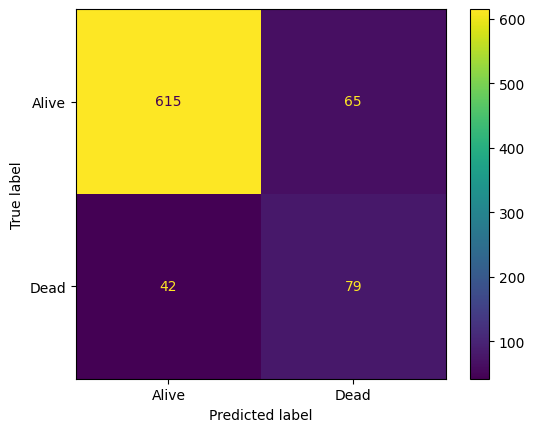

In [26]:
print("--------MATRIZ DE CONFUSIÓN--------")
ConfusionMatrixDisplay.from_estimator(
    grid_rf.best_estimator_,
    X_test,
    y_test,
    display_labels=le.classes_
)

In [27]:
importances_rf = best_rf.named_steps['classifier'].feature_importances_
features_rf = best_rf.named_steps['preprocessor'].get_feature_names_out()

df_importances_rf = pd.DataFrame({
    'Feature': features_rf,
    'Importance': importances_rf
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

print("\n --------IMPORTANCIA DE CARACTERÍSTICAS-------- ")
print(df_importances_rf)


 --------IMPORTANCIA DE CARACTERÍSTICAS-------- 
                                     Feature  Importance
0                 remainder__Survival Months    0.480454
1           remainder__Reginol Node Positive    0.083574
2                             remainder__Age    0.063064
3                      remainder__Tumor Size    0.059249
4          remainder__Regional Node Examined    0.047150
5                            cat__N Stage_N3    0.035436
6                        cat__6th Stage_IIIC    0.035149
7          cat__Progesterone Status_Positive    0.030246
8              cat__Estrogen Status_Positive    0.023493
9                               cat__Grade_3    0.021642
10  cat__differentiate_Poorly differentiated    0.019557
11               cat__Marital Status_Married    0.014054
12                           cat__N Stage_N2    0.010766
13    cat__differentiate_Well differentiated    0.010375
14                              cat__Grade_2    0.009928
15                          cat__T Sta

# Parte 2
 
Haga un modelo de boosting para predecir la variable **Status**.

Particione los datos en una proporción 80/20, haciendo `random_state=1`, y `stratify=y`.

El modelo debe ser sintonizado.

Reporte:
- El score de validación y los valores de los hiperparámetros sintonizados.
- El score de entrenamiento.
- El score de prueba.
- La matriz de confusión
- El reporte de clasificación.
- La importancia relativa de cada característica del modelo en un dataframe.

El objetivo es que el modelo supere el f1-macro score del modelo de regresión logísitca. Así:
- Si el recall obtenido es menor a 0.75, la máxima nota que obtendrá es 3.0.
- Si el recall obtenido es menor a 0.77, la máxima nota que obtendrá es 4.0.
- Si el recall obtenido es menor a 0.79, la máxima nota que obtendrá es 4.5.

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=1, stratify=y
)

num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')) 
])

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')), 
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

preprocessor_gb = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_cols),
        ('cat', cat_transformer, cat_cols)
    ]
)

In [33]:
gb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_gb),
    ('classifier', LGBMClassifier(random_state=1))
])

param_grid_gb = {
    'classifier__n_estimators': [100, 150, 200],       
    'classifier__learning_rate': [0.03, 0.05, 0.1],
    'classifier__max_depth': [4, 6, 8],
    'classifier__num_leaves': [15, 31, 50],
    'classifier__min_child_samples': [10, 20]
}

grid_gb = GridSearchCV(
    estimator=gb_pipeline,
    param_grid=param_grid_gb,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)

grid_gb.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 486, number of negative: 2718
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001162 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 358
[LightGBM] [Info] Number of data points in the train set: 3204, number of used features: 27
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.151685 -> initscore=-1.721443
[LightGBM] [Info] Start training from score -1.721443


,estimator,Pipeline(step...om_state=1))])
,param_grid,"{'classifier__learning_rate': [0.03, 0.05, ...], 'classifier__max_depth': [4, 6, ...], 'classifier__min_child_samples': [10, 20], 'classifier__n_estimators': [100, 150, ...], ...}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [39]:
print("--------RESULTADOS SINTONIZACIÓN--------")
print(f"Mejor puntaje de validación : {grid_gb.best_score_:.4f}")
print("Mejores hiperparámetros:\n")
for k, v in grid_gb.best_params_.items():
    print(f"{k}: {v}")

best_gb = grid_gb.best_estimator_
print(f"\nScore de Entrenamiento: {best_gb.score(X_train, y_train):.4f}")
print(f"Score de Prueba: {best_gb.score(X_test, y_test):.4f}\n")

y_pred_gb = best_gb.predict(X_test)
print("--------REPORTE DE CLASIFICACIÓN--------")
print(classification_report(y_test, y_pred_gb, target_names=le.classes_))


--------RESULTADOS SINTONIZACIÓN--------
Mejor puntaje de validación : 0.7831
Mejores hiperparámetros:

classifier__learning_rate: 0.03
classifier__max_depth: 6
classifier__min_child_samples: 10
classifier__n_estimators: 100
classifier__num_leaves: 15

Score de Entrenamiento: 0.9207
Score de Prueba: 0.9064

--------REPORTE DE CLASIFICACIÓN--------
              precision    recall  f1-score   support

       Alive       0.92      0.97      0.95       680
        Dead       0.79      0.52      0.63       121

    accuracy                           0.91       801
   macro avg       0.85      0.75      0.79       801
weighted avg       0.90      0.91      0.90       801



c:\Users\dagud\Documents\ap-2026-1-62\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\dagud\Documents\ap-2026-1-62\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\dagud\Documents\ap-2026-1-62\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


--------MATRIZ DE CONFUSIÓN--------


c:\Users\dagud\Documents\ap-2026-1-62\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


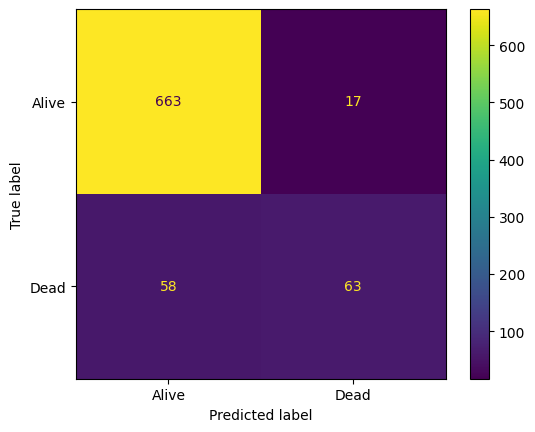

In [40]:
print("--------MATRIZ DE CONFUSIÓN--------")
ConfusionMatrixDisplay.from_estimator(
    grid_gb.best_estimator_,
    X_test,
    y_test,
    display_labels=le.classes_
)

In [41]:
importances_gb = best_gb.named_steps['classifier'].feature_importances_
features_gb = best_gb.named_steps['preprocessor'].get_feature_names_out()

df_importances_gb = pd.DataFrame({
    'Feature': features_gb,
    'Importance': importances_gb
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

print("\n--------IMPORTANCIA DE CARACTERÍSTICAS--------")
print(df_importances_gb)


--------IMPORTANCIA DE CARACTERÍSTICAS--------
                                     Feature  Importance
0                       num__Survival Months         380
1                                   num__Age         236
2                 num__Reginol Node Positive         228
3                num__Regional Node Examined         155
4                            num__Tumor Size         114
5   cat__differentiate_Poorly differentiated          63
6          cat__Progesterone Status_Positive          53
7                cat__Marital Status_Married          42
8              cat__Estrogen Status_Positive          31
9     cat__differentiate_Well differentiated          25
10             cat__Marital Status_Separated          13
11                          cat__T Stage _T4          12
12                          cat__T Stage _T2           9
13                        cat__6th Stage_IIB           9
14                           cat__Race_White           6
15                           cat__Race_O

# Condiciones de entrega de la evaluación:

- Debe entregar un archivo en formato .ipynb. No se admiten URLs.
- El código debe correr correctamente cuando las celdas se ejecutan de manera secuencial.
- Debe entregar el código ya ejecutado.
- Elimine previamente todo el código que sea basura (código redundante, funciones innecesarias, versiones preliminares de modelos). Solo entregue el código que de respuesta a lo que se le pide que haga.